# Packages 

In [1]:
import os
import json
import pdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Time series
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit

# SARIMAX 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler


# Jump Diffusion 
from sklearn.preprocessing import StandardScaler

# Process Track 
from tqdm import tqdm

# utilities

In [2]:
def get_online_quantile(scores, q_1, etas, alpha):
    """
    Computes the online quantile of a set of scores.
    :param scores: (np.array) The scores.
    :param q_1: (float) The quantile to compute.
    :param eta: (np.array) The sequence of learning rates.
    :return: (float) The sequence of online quantiles.
    """
    T = scores.shape[0]
    q = np.zeros(T)
    q[0] = q_1
    for t in range(T):
        err_t = (scores[t] > q[t]).astype(int)
        if t < T - 1:
            q[t + 1] = q[t] - etas[t] * (alpha - err_t)
    return q

In [3]:
def compute_coverage_metrics(Y, Yhat, alpha, epsilon, W, C):
    """
    Compute online quantiles, observed coverages, long-run coverage (LRC), 
    rolling coverage, and time-conditional coverage.

    Parameters:
        scores (numpy array): Array of scores for the main dataset.
        scores_val (numpy array): Array of scores for the validation dataset.
        alpha (float): 1 - alpha is the desired coverage level.
        epsilon (float): Decay parameter for eta in the decaying quantile.
        W (int): Window size for rolling coverage computation.
        C: Constant of etas decaying 

    Returns:
        dict: Dictionary containing all computed metrics.
    """
    scores = np.abs(Y - Yhat)
    #scores_val = scores[::2]
    #scores = scores[1::2]
    T = len(scores)
    #N_val = len(scores_val)
    
    # Define learning rates
    #etas_fixed = np.ones(T) * fixed_step_size
    etas_decaying = C * (np.array([1 / (t ** (1 / 2 + epsilon)) for t in range(1, T + 1)]))

    # Compute the oracle quantile
    #q_star = np.quantile(scores, 1 - alpha)
    
    # Initialize first quantile value
    q_1 = scores[0]

    # Compute online quantiles
    #q_fixed = get_online_quantile(scores, q_1, etas_fixed, alpha)
    q_decaying = get_online_quantile(scores, q_1, etas_decaying, alpha)

    # Compute observed coverage
    #observed_coverages_fixed = (scores <= q_fixed).astype(int)
    observed_coverages_decaying = (scores <= q_decaying).astype(int)
    #observed_coverages_oracle = (scores <= q_star).astype(int)

    # Compute long-run coverage
    #LRC_fixed = np.cumsum(observed_coverages_fixed) / (np.arange(len(observed_coverages_fixed)) + 1)
    LRC_decaying = np.cumsum(observed_coverages_decaying) / (np.arange(len(observed_coverages_decaying)) + 1)
    #LRC_qstar = np.cumsum(observed_coverages_oracle) / (np.arange(len(observed_coverages_oracle)) + 1)

    # Compute rolling coverage
    #rolling_coverage_fixed = smooth_array(observed_coverages_fixed, W)
    #rolling_coverage_decaying = smooth_array(observed_coverages_decaying, W)
    #rolling_coverage_oracle = smooth_array(observed_coverages_oracle, W)

    # Compute time-conditional coverage
    #time_coverage_fixed = (scores_val[:,None] <= q_fixed[None,:]).mean(axis=0)
    #time_coverage_decaying = (scores_val[:,None] <= q_decaying[None,:]).mean(axis=0)
    #time_coverage_qstar = (scores_val[:,None] <= q_star*np.ones_like(q_decaying)[None,:]).mean(axis=0)

    return {
        "T":T,
        #"q_fixed": q_fixed,
        "q_decaying": q_decaying,
        #"q_star": q_star,
        #"observed_coverages_fixed": observed_coverages_fixed,
        "observed_coverages_decaying": observed_coverages_decaying,
        #"observed_coverages_oracle": observed_coverages_oracle,
        #"LRC_fixed": LRC_fixed,
        "LRC_decaying": LRC_decaying,
        #"LRC_qstar": LRC_qstar,
        #"rolling_coverage_fixed": rolling_coverage_fixed,
        #"rolling_coverage_decaying": rolling_coverage_decaying,
        #"rolling_coverage_oracle": rolling_coverage_oracle,
        #"time_coverage_fixed": time_coverage_fixed,
        #"time_coverage_decaying": time_coverage_decaying,
        #"time_coverage_qstar": time_coverage_qstar
    }

In [4]:
def plot_coverage_results(results, alpha, W):
    """
    Plots the quantile evolution, long-run coverage
    for a single dataset using results from compute_coverage_metrics.

    Parameters:
        results (dict): Dictionary output from compute_coverage_metrics.
        alpha (float): 1 - alpha is the desired coverage level.
        W (int): Window size for rolling coverage computation.

    Returns:
        None (Displays the plot).
    """

    T = results['T']

    sns.set_style("white")
    sns.set_palette("Set2")

    # ---- Plot 1: Quantiles ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["q_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results["q_star"] * np.ones_like(results["q_decaying"]), label=r'$q^*$')
    plt.ylabel(r'$q_t$')
    plt.xlabel(r'time $t$')
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Long-run coverage ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["LRC_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results['LRC_qstar'], label=r'$q^*$')
    plt.axhline(y= (1 - alpha), linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')
    plt.xlabel(r'time $t$')
    plt.ylabel("long-run coverage")
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

In [5]:
# COMA 

def hedge(loss_matrix, eta):
    """
    Hedge algorithm.

    Parameters
    ----------
    loss_matrix : np.ndarray
        Shape (N, K), loss of K experts during N rounds.
    eta : float
        Learning rate parameter.

    Returns
    -------
    dict
        h : np.ndarray of shape (N,)
            Weighted average loss at each round.
        weights : np.ndarray of shape (N, K)
            Expert weights at each round.
    """
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)          # vector of length N
    weights = np.full((N, K), np.nan)  # N x K matrix
    w = np.full(K, 1.0 / K)         # start uniform weights

    for t in range(N):
        weights[t, :] = w
        w = w * np.exp(-eta * loss_matrix[t, :])  # exponential weighting
        w = w / np.sum(w)                         # normalize
        h[t] = np.sum(w * loss_matrix[t, :])      # weighted average loss

    return {"h": h, "weights": weights}


def counts_int(M, a, b, w):
    """
    Compute weighted fraction of intervals in M that cover the midpoint of [a,b].
    
    Parameters
    ----------
    M : np.ndarray
        Shape (n, 2), intervals with lower and upper bounds.
    a, b : float
        Interval boundaries.
    w : np.ndarray
        Weights for each interval (length n).
    
    Returns
    -------
    float
        Weighted mean (between 0 and 1).
    """
    mid = 0.5 * (a + b)
    inside = (M[:, 0] <= mid) & (mid <= M[:, 1]) 
    inside = inside.astype(float)                  
    num_int = np.average(inside, weights=w)
    return num_int


def mix(L, eta):
    """
    Python translation of R mix().
    """
    mn = np.min(L)

    if np.isinf(eta):
        w = (L == mn).astype(float)
        w /= w.sum()
    else:
        w = np.exp(-eta * (L - mn))

    s = np.sum(w)
    w = w / s
    M = mn - (1.0 / eta) * np.log(s / len(L)) if not np.isinf(eta) else mn

    return {"w": w, "M": M}

def adahedge(loss_matrix):
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)
    L = np.zeros(K)
    etas = np.full(N, np.nan)
    weights = np.full((N, K), np.nan)
    Delta = 0.0

    for t in range(N):
        eta = np.log(K) / Delta if Delta > 0 else np.inf
        result = mix(L, eta=eta)
        w, Mprev = result["w"], result["M"]

        h[t] = np.dot(w, loss_matrix[t])
        weights[t] = w
        L = L + loss_matrix[t]

        result = mix(L, eta=eta)
        delta = max(0.0, h[t] - (result["M"] - Mprev))
        Delta += delta
        etas[t] = eta

    return {"h": h, "weights": weights, "eta": etas}



def majority_vote(M, w, rho):
    breaks = np.unique(M.flatten())
    breaks.sort()

    lower, upper = [], []

    if np.mean(np.isinf(M[:, 1])) > rho:
        return np.array([[-np.inf, np.inf]])

    i = 0
    while i < len(breaks) - 1:
        cond = counts_int(M, breaks[i], breaks[i+1], w) > rho
        if cond:
            lower.append(breaks[i])
            j = i
            while j < len(breaks) - 1 and cond:
                j += 1
                if j < len(breaks) - 1:   
                    cond = counts_int(M, breaks[j], breaks[j+1], w) > rho
                else:
                    cond = False
            upper.append(breaks[j])
            i = j
        i += 1

    if not lower:
        return np.nan
    else:
        return np.column_stack([lower, upper])


def covr_fun(ci, target):
    """
    Coverage function: check if target lies inside interval(s).
    
    ci: np.ndarray (L, 2) or (2,), interval(s)
    target: float, true value
    
    Returns: 1 if covered, 0 otherwise
    """
    if isinstance(ci, float) and np.isnan(ci):
        return 0

    ci = np.atleast_2d(ci)
    covr = 0
    for l, u in ci:
        covr += int((l <= target) and (target <= u))
    return covr

import numpy as np

def loss_fun(ci):
    """
    Compute the width of confidence interval(s).
    
    Parameters
    ----------
    ci : np.ndarray or list
         - shape (2,)   → single interval [low, high]
         - shape (L, 2) → multiple intervals
         - np.nan       → no interval
    
    Returns
    -------
    float
        total width (sum of all intervals' widths)
    """

    if ci is None or (isinstance(ci, float) and np.isnan(ci)):
        return 0.0
    ci = np.atleast_2d(ci)
    
    width = 0.0
    for l, u in ci:
        if np.isnan(l) or np.isnan(u):
            continue
        width += (u - l)
    return width

import numpy as np

def coma_loop(intervals_list, weights, data_y):
    """
    COMA aggregation loop (Python translation of the R code).
    
    intervals_list: list of arrays [N x 2], one for each expert's intervals
    weights: array [N x K], AdaHedge weights
    data_y: array of true outcomes
    """
    N, K = weights.shape
    pi_m, pi_wm = [], []
    m_cov, wm_cov = [], []

    for i in range(N):
        # stack intervals from all experts for round i
        conf_t = np.vstack([intervals[i] for intervals in intervals_list])

        # deterministic majority vote (rho=0.5 for strict majority)
        maj_int = majority_vote(conf_t, w=weights[i], rho=0.5)

        # randomized majority vote (rho ∈ [0.5,1])
        rho_rand = np.random.uniform(0.5, 1.0)
        wmaj_int = majority_vote(conf_t, w=weights[i], rho=rho_rand)

        # store intervals
        pi_m.append(maj_int)
        pi_wm.append(wmaj_int)

        # coverage check (ensure index alignment!)
        target_idx = i
        if target_idx < len(data_y):
            m_cov.append(covr_fun(maj_int, data_y[target_idx]))
            wm_cov.append(covr_fun(wmaj_int, data_y[target_idx]))
        else:
            m_cov.append(0)
            wm_cov.append(0)

    return {
        "pi_m": pi_m,
        "pi_wm": pi_wm,
        "m_cov": np.array(m_cov),
        "wm_cov": np.array(wm_cov),
        "mean_m_cov": np.mean(m_cov),
        "mean_wm_cov": np.mean(wm_cov)
    }

In [6]:
# Simple average ensemble 

def simple_average_ensemble(predictions):
    """
    Simple average ensemble of multiple model predictions.

    Parameters:
        predictions (list of np.array): List of prediction arrays from different models.

    Returns:
        np.array: Ensemble predictions obtained by averaging.
    """
    return np.mean(predictions, axis=0)

# ELEC2

In [7]:
elec = pd.read_csv("/Users/victoria/Desktop/2025/STAT490/electricity-normalized.csv")
elec.head()
first_change = np.where(elec['transfer'] != elec['transfer'].iloc[0])[0][0]
elec = elec.iloc[first_change:].reset_index(drop=True)

time_ran = [9*2/48, 0.5]
elec = elec[(elec['period'] >= time_ran[0]) & (elec['period'] <= time_ran[1])]
elec = elec.iloc[:, 3:8] 

max_lag = 6
elec_lag = np.column_stack([elec['transfer'].shift(l) for l in range(max_lag, 0, -1)])
elec_lag = elec_lag[max_lag:]

elec = elec.iloc[max_lag:].reset_index(drop=True)
elec_y = elec['transfer'].values
elec_x = elec.iloc[:, 0:4].values 

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

def get_preds(Y, X, tinit=100):
    """
    One-step-ahead rolling linear regression forecast (R baseline equivalent).
    """
    T = len(Y)
    preds = []

    for t in range(tinit, T):
        # Fit up to (t-1)
        model = LinearRegression().fit(X[:t], Y[:t])
        # Predict at time t (next observation)
        pred_t = model.predict(X[t:t+1])[0]
        preds.append(pred_t)

    return np.array(preds)

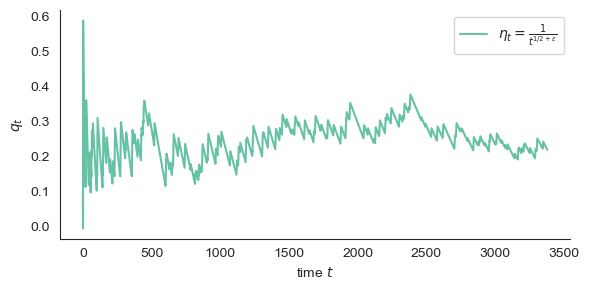

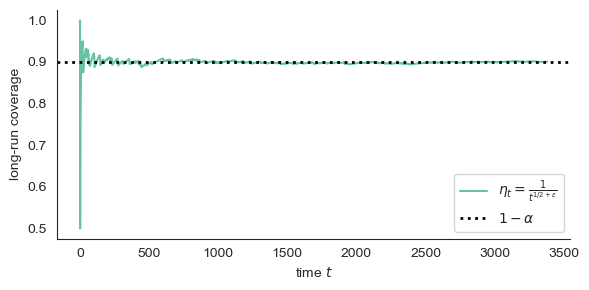

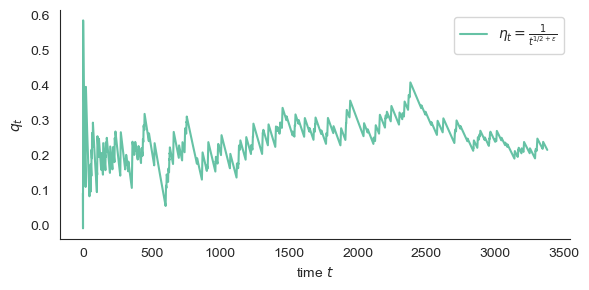

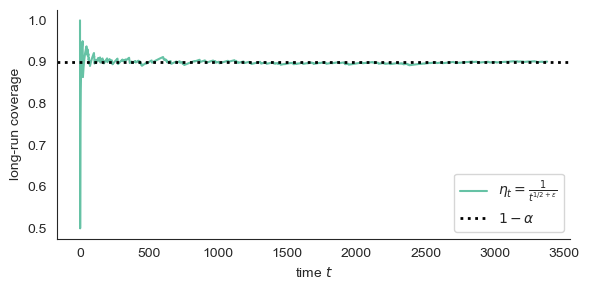

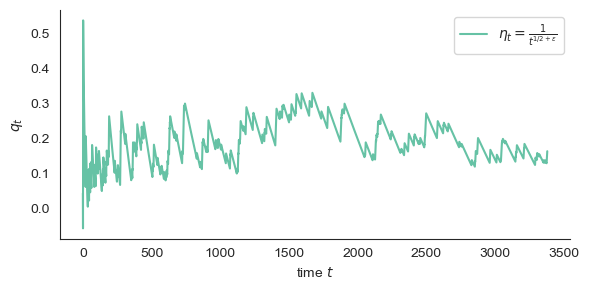

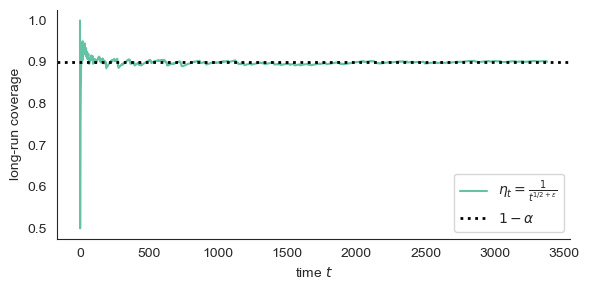

In [9]:
seed = 42
np.random.seed(seed)
y_true_aligned = elec_y[100:]
# AR(2)
y_pred_ar2 = get_preds(elec_y, elec_lag[:, :2], tinit=100)
ar2_met = compute_coverage_metrics(y_true_aligned, y_pred_ar2, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(ar2_met, alpha=0.1, W=1000)
CI_ar2_decaying = ar2_met['q_decaying'] * 2
# AR(2) + covariate
X_ar2_cov = np.column_stack([elec_lag[:, :2], elec_x[:, 0]])
y_pred_ar2_cov = get_preds(elec_y, X_ar2_cov, tinit=100)
ar2_cov_met = compute_coverage_metrics(y_true_aligned, y_pred_ar2_cov, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(ar2_cov_met, alpha=0.1, W=1000)
CI_ar2_cov_decaying = ar2_cov_met['q_decaying'] * 2
# Only covariate
y_pred_cov = get_preds(elec_y, elec_x, tinit=100)
cov_met = compute_coverage_metrics(y_true_aligned, y_pred_cov, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(cov_met, alpha=0.1, W=1000)
CI_cov_decaying = cov_met['q_decaying'] * 2

In [10]:
print(f'mean coverage for covarite is:', np.mean(cov_met['observed_coverages_decaying']))
print(f'mean coverage for ar2+cov is:', np.mean(ar2_cov_met['observed_coverages_decaying']))
print(f'mean coverage for ar is:', np.mean(ar2_met['observed_coverages_decaying']))

mean coverage for covarite is: 0.9005917159763314
mean coverage for ar2+cov is: 0.900887573964497
mean coverage for ar is: 0.900887573964497


In [11]:
print("elec_y:", len(elec_y))
print("y_true_aligned:", len(y_true_aligned))
print("y_pred_ar2:", len(y_pred_ar2))
print("ar2_met['q_decaying']:", len(ar2_met["q_decaying"]))
print("ar2_met['LRC_decaying']:", len(ar2_met["LRC_decaying"]))

elec_y: 3480
y_true_aligned: 3380
y_pred_ar2: 3380
ar2_met['q_decaying']: 3380
ar2_met['LRC_decaying']: 3380


# Simple Average 

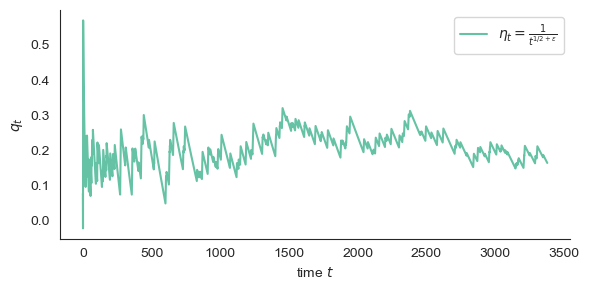

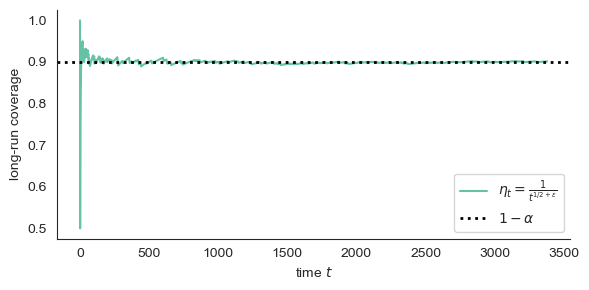

0.20637942914879395


In [12]:
y_sa_pred = simple_average_ensemble([y_pred_ar2, y_pred_ar2_cov, y_pred_cov])
results_sa = compute_coverage_metrics(y_true_aligned, y_sa_pred, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_sa, alpha=0.1, W=1000)
print(np.mean(results_sa['q_decaying']))
CI_sa_decaying = results_sa['q_decaying'] * 2

# Super Learner 

Fold 0: train=565, val=563
  preds_val.shape=(563, 3), val_idx len=563
Fold 1: train=1128, val=563
  preds_val.shape=(563, 3), val_idx len=563
Fold 2: train=1691, val=563
  preds_val.shape=(563, 3), val_idx len=563
Fold 3: train=2254, val=563
  preds_val.shape=(563, 3), val_idx len=563
Fold 4: train=2817, val=563
  preds_val.shape=(563, 3), val_idx len=563
Final meta-learner weights: [0.24009628 0.20702594 0.55287778]


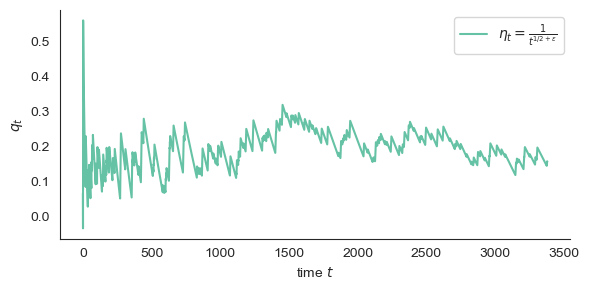

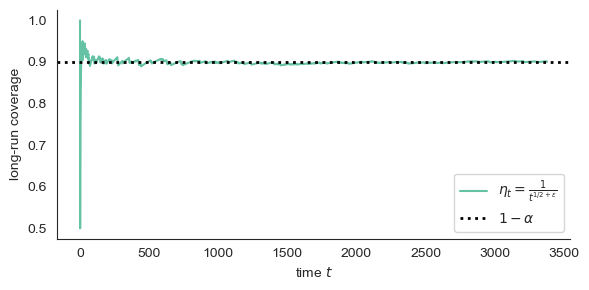

In [13]:
from sklearn.model_selection import TimeSeriesSplit
from scipy.optimize import minimize
import numpy as np

tinit = 100

from sklearn.model_selection import TimeSeriesSplit
from scipy.optimize import minimize
import numpy as np

tinit = 100

def base_preds(val_idx):
    """
    Generate OOF predictions for validation window using baseline get_preds().
    Matches GARCH-style indexing: use full data up to end of val_idx,
    then keep only the last len(val_idx) predictions.
    """
    cutoff = val_idx[-1] + 1
    y_sub, lag_sub, x_sub = elec_y[:cutoff], elec_lag[:cutoff, :], elec_x[:cutoff, :]

    # Base learners
    pred_ar2 = get_preds(y_sub, lag_sub[:, :2], tinit=tinit)
    pred_ar2_cov = get_preds(y_sub, np.column_stack([lag_sub[:, :2], x_sub[:, 0]]), tinit=tinit)
    pred_cov = get_preds(y_sub, x_sub, tinit=tinit)

    preds_ar2_val = pred_ar2[-len(val_idx):]
    preds_ar2_cov_val = pred_ar2_cov[-len(val_idx):]
    preds_cov_val = pred_cov[-len(val_idx):]

    return np.column_stack([
        preds_ar2_val,
        preds_ar2_cov_val,
        preds_cov_val
    ])

def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    """Optimize convex weights under simplex constraints."""
    init_phi = np.ones(X.shape[1]) / X.shape[1]

    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2

    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]
    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x

def super_learner_elec(elec_y, elec_lag, elec_x, tinit=100, n_splits=5):
    """
    Super Learner for ELEC2:
      Base models: AR(2), AR(2)+cov, cov-only.
    Uses TimeSeriesSplit CV and convex weighting of OOF predictions.
    """
    y_true = elec_y[tinit:]
    meta_features = np.full((len(y_true), 3), np.nan)

    tscv = TimeSeriesSplit(n_splits=n_splits)

    # --- Cross-validation loop ---
    for fold, (train_idx, val_idx) in enumerate(tscv.split(y_true)):
        print(f"Fold {fold}: train={len(train_idx)}, val={len(val_idx)}")

        # Shift validation indices to full data space (+tinit)
        val_idx_full = val_idx + tinit
        preds_val = base_preds(val_idx_full)

        # Fill meta_features (aligned with post–tinit y_true)
        meta_features[val_idx, :] = preds_val

        print(f"  preds_val.shape={preds_val.shape}, val_idx len={len(val_idx)}")

    valid_rows = ~np.isnan(meta_features).any(axis=1)
    X_meta_cv = meta_features[valid_rows]
    y_meta_cv = y_true[valid_rows]

    meta_weights = optimize_weights(X_meta_cv, y_meta_cv)
    print("Final meta-learner weights:", meta_weights)

    y_pred_ar2 = get_preds(elec_y, elec_lag[:, :2], tinit=tinit)
    y_pred_ar2_cov = get_preds(elec_y, np.column_stack([elec_lag[:, :2], elec_x[:, 0]]), tinit=tinit)
    y_pred_cov = get_preds(elec_y, elec_x, tinit=tinit)

    X_meta_full = np.column_stack([y_pred_ar2, y_pred_ar2_cov, y_pred_cov])
    super_preds = X_meta_full @ meta_weights

    return super_preds, meta_weights

super_preds, meta_weights = super_learner_elec(elec_y, elec_lag, elec_x, tinit=100, n_splits=5)

super_met = compute_coverage_metrics(
    elec_y[tinit:], super_preds,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)
plot_coverage_results(super_met, alpha=0.1, W=1000)
CI_sl_decaying = super_met['q_decaying'] * 2

In [14]:
print(f'mean coverage for Super Learner is:', np.mean(super_met['observed_coverages_decaying']))


mean coverage for Super Learner is: 0.900887573964497


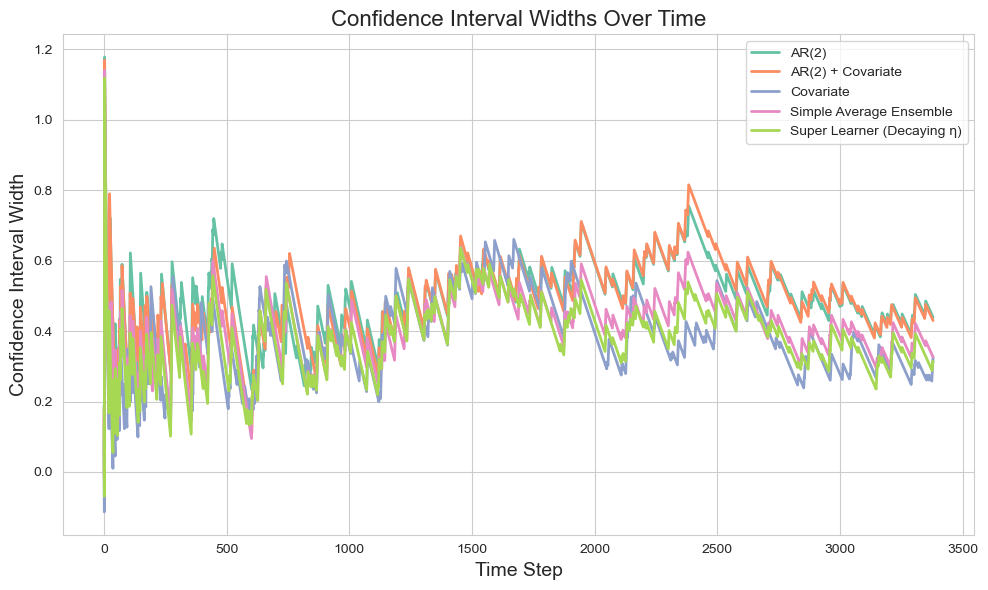

In [15]:
## line comparison plot 
## store important result to one file

import matplotlib.pyplot as plt

# Step 1: Generate a common index (e.g., time steps)
n = len(CI_cov_decaying)
x = list(range(n))  # n is the number of CI values

# Step 2: Plot setup
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Step 3: Plot each method's CI width as a line
plt.plot(x, CI_ar2_decaying[-n:], label='AR(2)', linewidth=2)
plt.plot(x, CI_ar2_cov_decaying[-n:], label='AR(2) + Covariate', linewidth=2)
plt.plot(x, CI_cov_decaying, label='Covariate', linewidth=2)
plt.plot(x, CI_sa_decaying[-n:], label='Simple Average Ensemble', linewidth=2)
plt.plot(x, CI_sl_decaying[-n:], label='Super Learner (Decaying η)', linewidth=2)


# Step 4: Enhance plot readability
plt.title('Confidence Interval Widths Over Time', fontsize=16)
plt.xlabel('Time Step', fontsize=14)
plt.ylabel('Confidence Interval Width', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


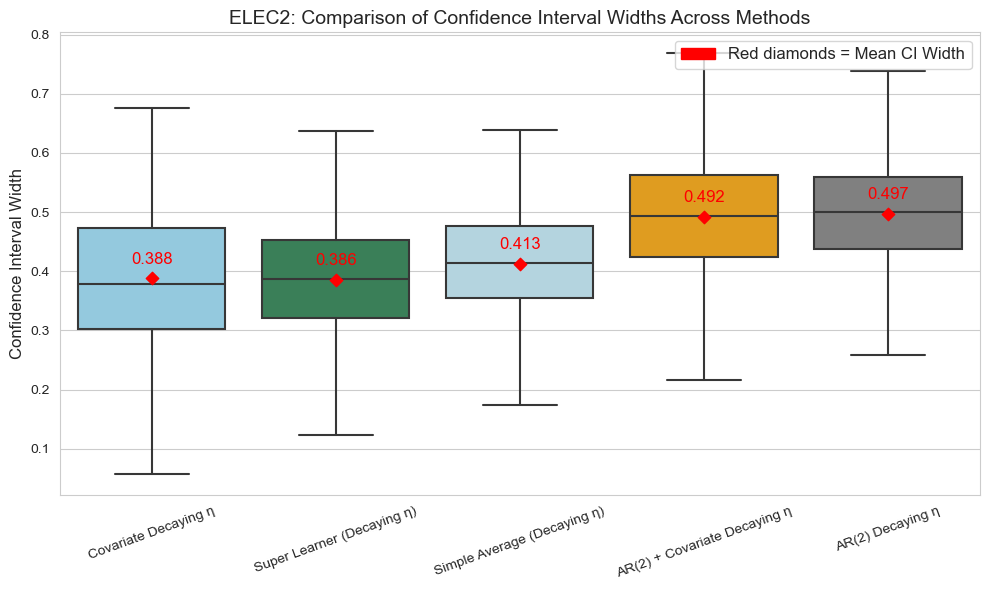

In [16]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
# Step 1: Collect all CI width arrays into a dictionary
data_dict = {
    "AR(2) Decaying η": CI_ar2_decaying,
    "AR(2) + Covariate Decaying η": CI_ar2_cov_decaying,
    "Covariate Decaying η": CI_cov_decaying,
    "Simple Average (Decaying η)": CI_sa_decaying,
    "Super Learner (Decaying η)": CI_sl_decaying
}

# Step 2: Convert to long-format DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Step 3: Define custom order by median CI width
order = df_long.groupby("Method")["CI Width"].median().sort_values().index

# Step 4: Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
palette = {
    "AR(2) Decaying η": "gray",
    "AR(2) + Covariate Decaying η": "orange",
    "Covariate Decaying η": "skyblue",
    "Simple Average (Decaying η)": "lightblue",
    "Super Learner (Decaying η)": "seagreen"
}

ax = sns.boxplot(x="Method", y="CI Width", data=df_long, order=order,
                 palette=palette, showfliers=False)

# Add mean points
means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(order):
    ax.scatter(i, means[method], color="red", marker="D", s=40, zorder=3)
    ax.text(i, means[method]+0.02, f"{means[method]:.3f}",
            ha='center', va='bottom', fontsize=12, color="red")

# Step 5: Add custom legend entry for red mean points
mean_patch = mpatches.Patch(color='red', label='Red diamonds = Mean CI Width')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [mean_patch], labels + ['Red diamonds = Mean CI Width'],
          loc='upper right', fontsize=12, frameon=True)

# Step 6: Enhance readability
plt.title("ELEC2: Comparison of Confidence Interval Widths Across Methods", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



# COMA 

Mean deterministic coverage: 0.9005917159763314
Mean randomized coverage: 0.9005917159763314
Mean CI width — COMA (det): 0.3880001153449448
Mean CI width — COMA (rand): 0.38797184474211105
Mean CI width — Super Learner: 0.38579155745514687


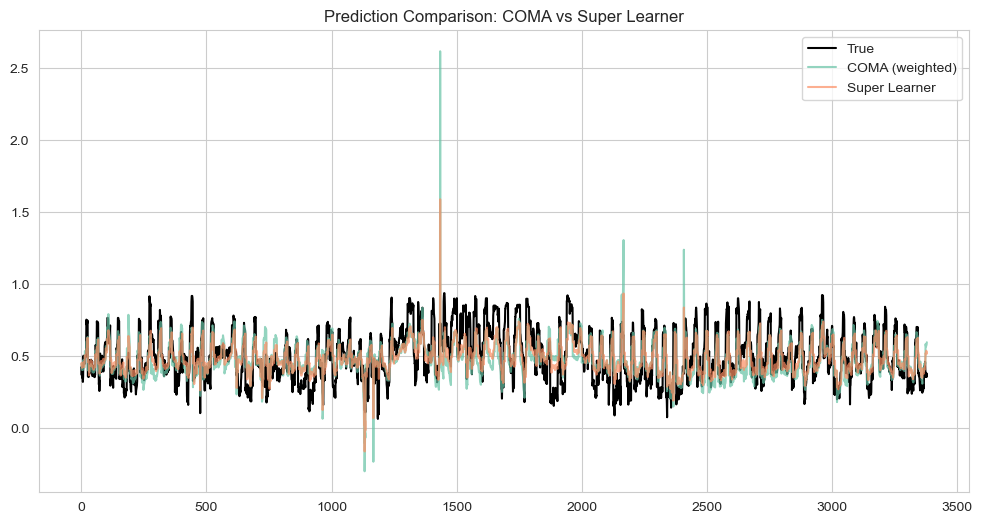

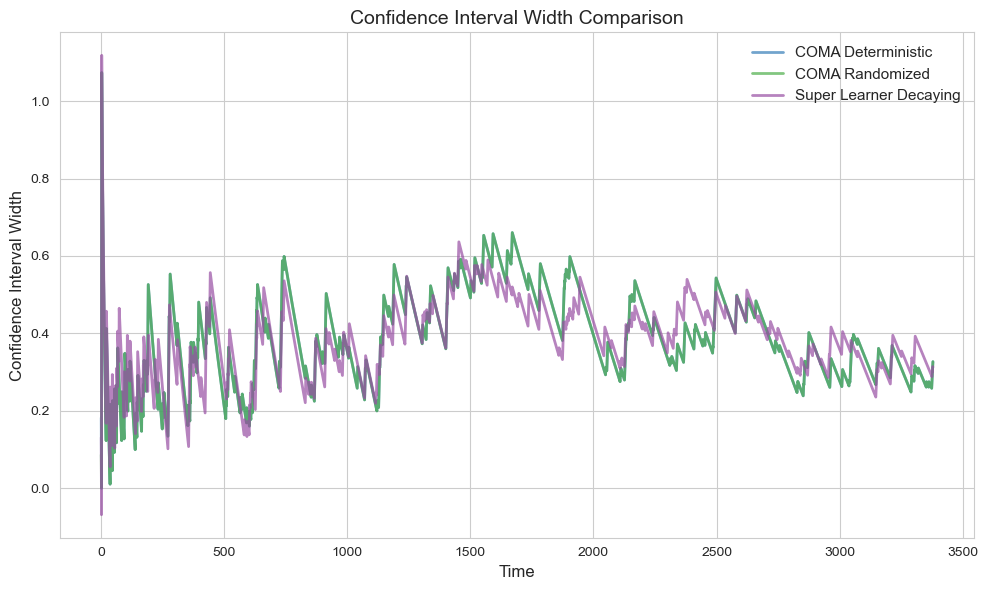

In [17]:
# --- Step 1: Minimum aligned length ---
min_len = min(
    len(ar2_met['q_decaying']),
    len(ar2_cov_met['q_decaying']),
    len(cov_met['q_decaying']),
    len(CI_sl_decaying),
    len(elec_y[tinit:])  # already aligned after tinit
)

# --- Step 2: CI half-widths (2 * q_decaying) for base learners ---
ci_matrix = np.column_stack([
    CI_ar2_decaying[-min_len:],       # AR(2)
    CI_ar2_cov_decaying[-min_len:],   # AR(2) + covariate
    CI_cov_decaying[-min_len:]        # Covariate only
])

# Hedge weights across experts (AdaHedge)
adahedAlg = adahedge(loss_matrix=ci_matrix)
weights_plain = adahedAlg["weights"]

# --- Step 3: Build prediction intervals for each base learner ---
intervals_ar2 = np.column_stack([
    y_pred_ar2[-min_len:] - ar2_met['q_decaying'][-min_len:],
    y_pred_ar2[-min_len:] + ar2_met['q_decaying'][-min_len:]
])

intervals_ar2_cov = np.column_stack([
    y_pred_ar2_cov[-min_len:] - ar2_cov_met['q_decaying'][-min_len:],
    y_pred_ar2_cov[-min_len:] + ar2_cov_met['q_decaying'][-min_len:]
])

intervals_cov = np.column_stack([
    y_pred_cov[-min_len:] - cov_met['q_decaying'][-min_len:],
    y_pred_cov[-min_len:] + cov_met['q_decaying'][-min_len:]
])

intervals_list_plain = [intervals_ar2, intervals_ar2_cov, intervals_cov]

# --- Step 4: Align test labels ---
y_test_aligned = elec_y[tinit:][-min_len:]

# --- Step 5: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean deterministic coverage:", result_plain["mean_m_cov"])
print("Mean randomized coverage:", result_plain["mean_wm_cov"])

# --- Step 6: Compute widths ---
pi_m   = result_plain["pi_m"]   # deterministic intervals
pi_wm  = result_plain["pi_wm"]  # randomized intervals

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sl_decaying[-min_len:]

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

# --- Step 7: Compare predictions ---
base_preds_matrix = np.column_stack([
    y_pred_ar2[-min_len:], 
    y_pred_ar2_cov[-min_len:], 
    y_pred_cov[-min_len:]
])

# Case 1: weights_plain is shape (n, k)
coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

# --- Step 8: Plot CI widths ---
colors = sns.color_palette("Set1", 4)
plt.figure(figsize=(10, 6))
plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner Decaying', linewidth=2, alpha=0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)
plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

Text(0.1, 0.95, 'Mean CI width:\nCOMA(base) = 0.3880\nSL = 0.3858')

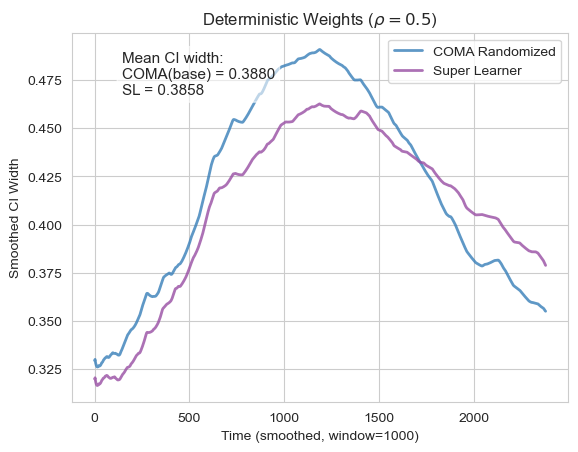

In [18]:
# smooth
# --- Helper function for smoothing ---
def smooth_series(series, window=500):
    return np.convolve(series, np.ones(window)/window, mode='valid')
window = 1000  # smoothing window size
# --- Deterministic subplot (smoothed) ---
plt.plot(smooth_series(coma_width_rand, window), label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[1])
plt.plot(smooth_series(CI_sl_decaying, window), label='Super Learner', linewidth=2, alpha=0.8, color=colors[3])
plt.title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
plt.xlabel("Time (smoothed, window=1000)")
plt.ylabel("Smoothed CI Width")
plt.legend()

mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(CI_sl_decaying)
plt.text(0.1, 0.95,
         f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nSL = {mean_rand_sl:.4f}",
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

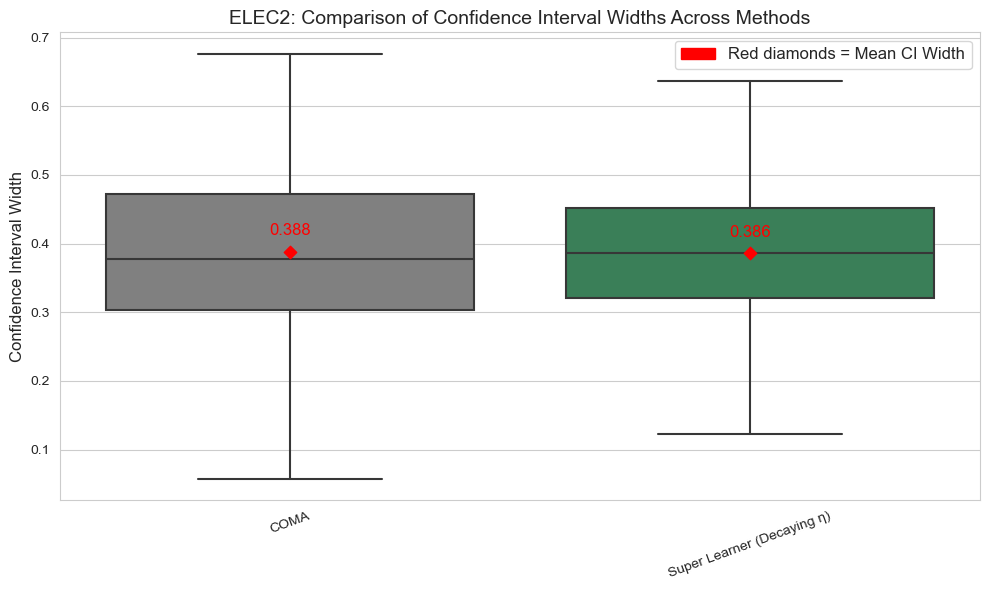

In [19]:


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
# Step 1: Collect all CI width arrays into a dictionary
data_dict = {
    "COMA": coma_width_det,
    "Super Learner (Decaying η)": CI_super_decaying
}

# Step 2: Convert to long-format DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Step 3: Define custom order by median CI width
order = df_long.groupby("Method")["CI Width"].median().sort_values().index

# Step 4: Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
palette = {
    "COMA": "gray",
    "Super Learner (Decaying η)": "seagreen"
}

ax = sns.boxplot(x="Method", y="CI Width", data=df_long, order=order,
                 palette=palette, showfliers=False)

# Add mean points
means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(order):
    ax.scatter(i, means[method], color="red", marker="D", s=40, zorder=3)
    ax.text(i, means[method]+0.02, f"{means[method]:.3f}",
            ha='center', va='bottom', fontsize=12, color="red")

# Step 5: Add custom legend entry for red mean points
mean_patch = mpatches.Patch(color='red', label='Red diamonds = Mean CI Width')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [mean_patch], labels + ['Red diamonds = Mean CI Width'],
          loc='upper right', fontsize=12, frameon=True)

# Step 6: Enhance readability
plt.title("ELEC2: Comparison of Confidence Interval Widths Across Methods", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



# COMA+SL

Mean deterministic coverage(+SL): 0.899112426035503
Mean randomized coverage(+SL): 0.899112426035503
Mean CI width — COMA (det): 0.3880001153449448
Mean CI width — COMA (rand): 0.38797184474211105
Mean CI width — COMA (det) + SL: 0.3858613101939558
Mean CI width — COMA (rand) + SL: 0.3857373394407624


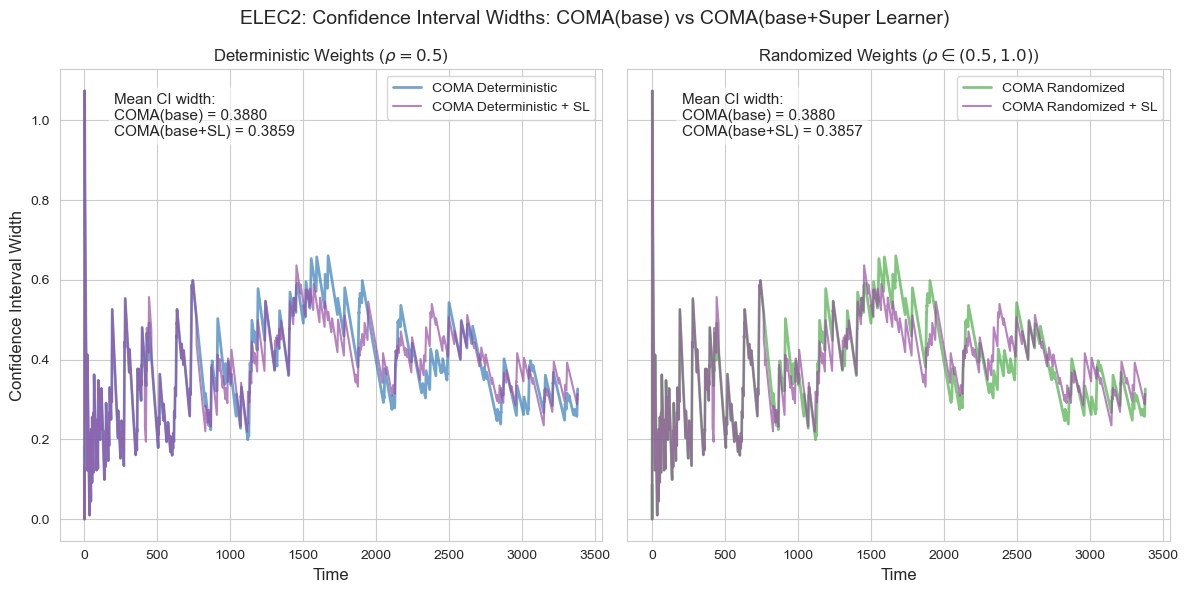

In [20]:

min_len = min(
    len(ar2_met['q_decaying']),
    len(ar2_cov_met['q_decaying']),
    len(cov_met['q_decaying']),
    len(super_met['q_decaying']),
    len(elec_y[tinit:])   # already aligned after tinit
)

CI_ar2_decaying      = 2 * ar2_met['q_decaying'][-min_len:]
CI_ar2_cov_decaying  = 2 * ar2_cov_met['q_decaying'][-min_len:]
CI_cov_decaying      = 2 * cov_met['q_decaying'][-min_len:]
CI_sl_decaying       = 2 * super_met['q_decaying'][-min_len:]

ci_matrix_sl = np.column_stack([
    CI_ar2_decaying,
    CI_ar2_cov_decaying,
    CI_cov_decaying,
    CI_sl_decaying
])
adahedAlg_sl = adahedge(loss_matrix=ci_matrix_sl)
weights_sl = adahedAlg_sl["weights"]

intervals_ar2 = np.column_stack([
    y_pred_ar2[-min_len:] - ar2_met['q_decaying'][-min_len:],
    y_pred_ar2[-min_len:] + ar2_met['q_decaying'][-min_len:]
])

intervals_ar2_cov = np.column_stack([
    y_pred_ar2_cov[-min_len:] - ar2_cov_met['q_decaying'][-min_len:],
    y_pred_ar2_cov[-min_len:] + ar2_cov_met['q_decaying'][-min_len:]
])

intervals_cov = np.column_stack([
    y_pred_cov[-min_len:] - cov_met['q_decaying'][-min_len:],
    y_pred_cov[-min_len:] + cov_met['q_decaying'][-min_len:]
])

intervals_sl = np.column_stack([
    super_preds[-min_len:] - super_met['q_decaying'][-min_len:],
    super_preds[-min_len:] + super_met['q_decaying'][-min_len:]
])


y_test_aligned = elec_y[tinit:][-min_len:]

intervals_list_base = [intervals_ar2, intervals_ar2_cov, intervals_cov]
result_base = coma_loop(intervals_list_base, weights_sl[:, :3], y_test_aligned)

pi_m_base  = result_base["pi_m"]
pi_wm_base = result_base["pi_wm"]

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm_base])

intervals_list_sl = [intervals_ar2, intervals_ar2_cov, intervals_cov, intervals_sl]
result_sl = coma_loop(intervals_list_sl, weights_sl, y_test_aligned)
print("Mean deterministic coverage(+SL):", result_sl["mean_m_cov"])
print("Mean randomized coverage(+SL):", result_sl["mean_wm_cov"])
pi_m_sl  = result_sl["pi_m"]
pi_wm_sl = result_sl["pi_wm"]

coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA (det) + SL:", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA (rand) + SL:", np.nanmean(coma_width_rand_sl))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color=colors[1])
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color=colors[3])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# Randomized subplot
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color=colors[2])
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("ELEC2: Confidence Interval Widths: COMA(base) vs COMA(base+Super Learner)", fontsize=14)
plt.tight_layout()
plt.show()


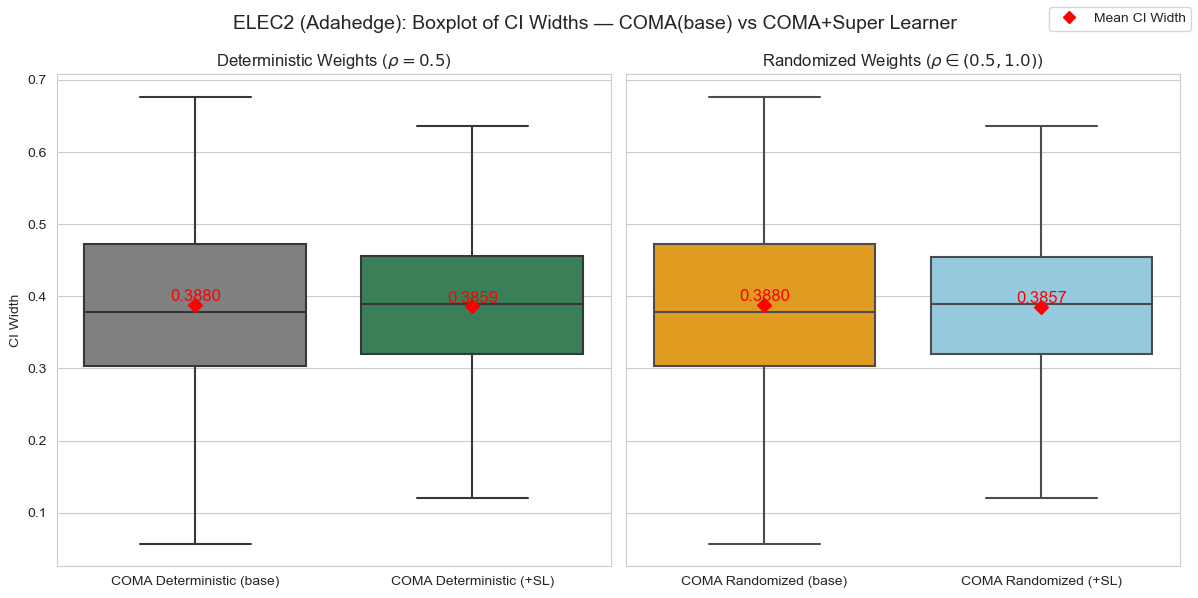

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Collect into dictionary
data_dict = {
    "COMA Deterministic (base)": coma_width_det,
    "COMA Deterministic (+SL)": coma_width_det_sl,
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

# Convert to DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Split deterministic vs randomized
det_methods = ["COMA Deterministic (base)", "COMA Deterministic (+SL)"]
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

palette = {"COMA Deterministic (base)": "gray",
           "COMA Deterministic (+SL)": "seagreen",
           "COMA Randomized (base)": "orange",
           "COMA Randomized (+SL)": "skyblue"}

# --- Deterministic subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(det_methods)],
            order=det_methods, palette=palette, showfliers=False, ax=axes[0])

means_det = [np.nanmean(data_dict[m]) for m in det_methods]
for i, m in enumerate(det_methods):
    axes[0].scatter(i, means_det[i], color="red", marker="D", s=50, zorder=3)
    axes[0].text(i, means_det[i]+0.005, f"{means_det[i]:.4f}", ha='center', fontsize=12, color="red")

axes[0].set_title("Deterministic Weights ($\\rho=0.5$)")
axes[0].set_xlabel("")
axes[0].set_ylabel("CI Width")

# --- Randomized subplot ---
sns.boxplot(x="Method", y="CI Width", data=df_long[df_long["Method"].isin(rand_methods)],
            order=rand_methods, palette=palette, showfliers=False, ax=axes[1])

means_rand = [np.nanmean(data_dict[m]) for m in rand_methods]
for i, m in enumerate(rand_methods):
    axes[1].scatter(i, means_rand[i], color="red", marker="D", s=50, zorder=3)
    axes[1].text(i, means_rand[i]+0.005, f"{means_rand[i]:.4f}", ha='center', fontsize=12, color="red")

axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

# Legend for red diamond
fig.legend(handles=[plt.Line2D([0],[0], color='red', marker='D', linestyle='', label='Mean CI Width')],
           loc='upper right')

plt.suptitle("ELEC2 (Adahedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

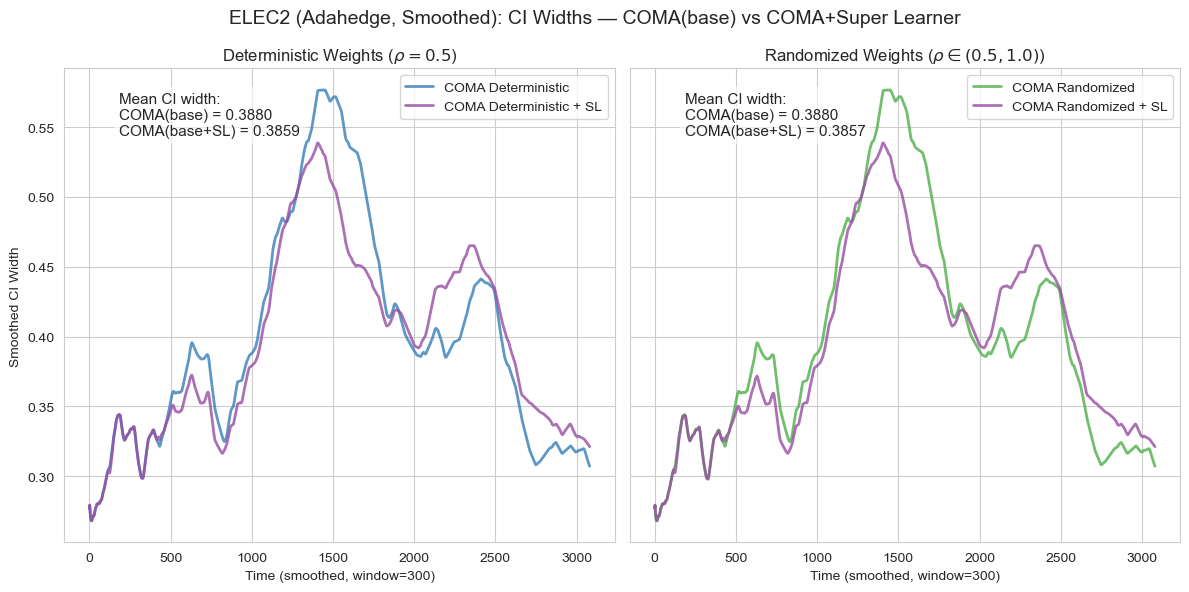

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

window = 300  # smoothing window size

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Deterministic subplot (smoothed)
axes[0].plot(smooth_series(coma_width_det, window), label='COMA Deterministic', linewidth=2, alpha=0.8, color=colors[1])
axes[0].plot(smooth_series(coma_width_det_sl, window), label='COMA Deterministic + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time (smoothed, window=300)")
axes[0].set_ylabel("Smoothed CI Width")
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# Randomized subplot (smoothed)
axes[1].plot(smooth_series(coma_width_rand, window), label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(smooth_series(coma_width_rand_sl, window), label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time (smoothed, window=300)")
axes[1].legend()


mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("ELEC2 (Adahedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

## Hedge 

Mean deterministic coverage (COMA base): 0.9005917159763314
Mean randomized coverage (COMA base): 0.8979289940828402
Mean deterministic coverage (COMA+SL): 0.8994082840236687
Mean randomized coverage (COMA+SL): 0.8822485207100592
Mean CI width — COMA(base, det): 0.3899546343292556
Mean CI width — COMA(base, rand): 0.38735169760900134
Mean CI width — COMA(base+SL, det): 0.38758153775620935
Mean CI width — COMA(base+SL, rand): 0.36661776742475133


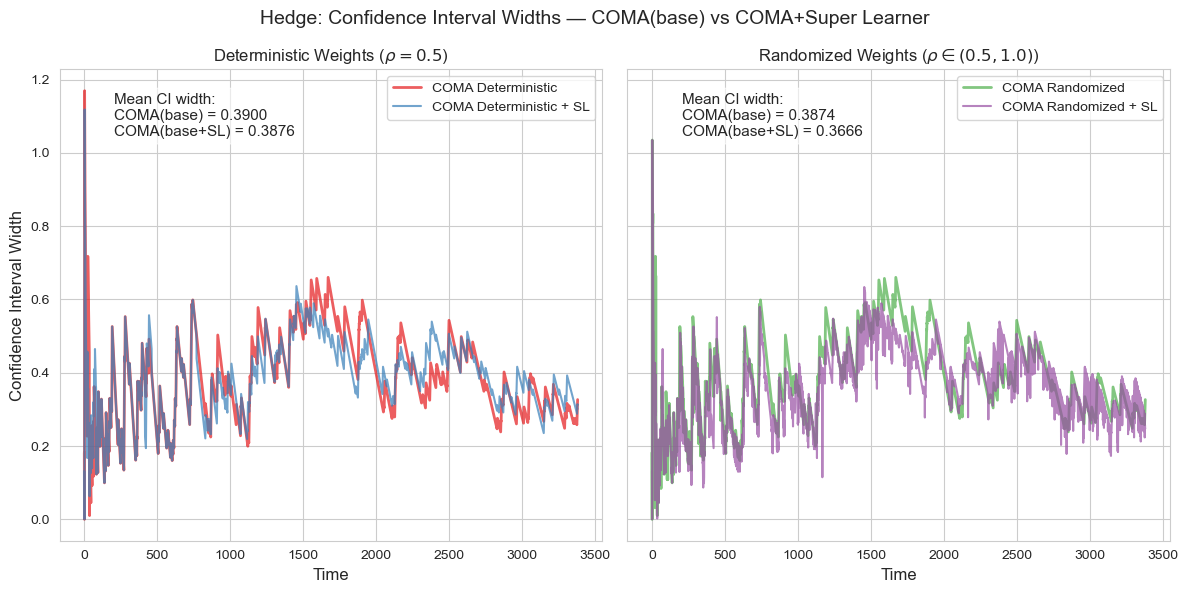

In [23]:
# --- Step 1: Run Hedge separately for base (3 experts) and base+SL (4 experts) ---
hedAlg_base = hedge(ci_matrix, eta=0.1)        # shape (N,3)
hedAlg_sl   = hedge(ci_matrix_sl, eta=0.1)     # shape (N,4)

weights_base = hedAlg_base["weights"]
weights_sl   = hedAlg_sl["weights"]

N_base, K_base = weights_base.shape
N_sl, K_sl     = weights_sl.shape

# Ensure test labels align correctly with the shorter horizon
min_len = min(len(elec_y[tinit:]), N_base, N_sl)
y_test_aligned = elec_y[tinit:][-min_len:]

pi_m_base, pi_wm_base = [], []
pi_m_sl, pi_wm_sl     = [], []

m_cov_base = np.full(min_len, np.nan)
wm_cov_base = np.full(min_len, np.nan)
m_cov_sl   = np.full(min_len, np.nan)
wm_cov_sl  = np.full(min_len, np.nan)

# --- Step 3: Loop over time (like R's for(i in 1:N)) ---
for i in range(min_len):
    # --- Base (3 experts) ---
    conf_base = np.vstack([intervals_list_base[j][i] for j in range(len(intervals_list_base))])
    maj_int_base  = majority_vote(conf_base, w=weights_base[i], rho=0.5)
    wmaj_int_base = majority_vote(conf_base, w=weights_base[i], rho=np.random.uniform(0.5, 1.0))

    pi_m_base.append(maj_int_base)
    pi_wm_base.append(wmaj_int_base)
    m_cov_base[i]  = covr_fun(maj_int_base, y_test_aligned[i])
    wm_cov_base[i] = covr_fun(wmaj_int_base, y_test_aligned[i])

    # --- Base+SL (4 experts) ---
    conf_sl = np.vstack([intervals_list_sl[j][i] for j in range(len(intervals_list_sl))])
    maj_int_sl  = majority_vote(conf_sl, w=weights_sl[i], rho=0.5)
    wmaj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=np.random.uniform(0.5, 1.0))

    pi_m_sl.append(maj_int_sl)
    pi_wm_sl.append(wmaj_int_sl)
    m_cov_sl[i]  = covr_fun(maj_int_sl, y_test_aligned[i])
    wm_cov_sl[i] = covr_fun(wmaj_int_sl, y_test_aligned[i])


# --- Step 4: Compute widths ---
coma_width_det     = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

# --- Step 5: Summaries ---
print("Mean deterministic coverage (COMA base):", np.nanmean(m_cov_base))
print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean deterministic coverage (COMA+SL):", np.nanmean(m_cov_sl))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))

# --- Step 7: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color=colors[0])
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color=colors[1])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color=colors[2])
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Hedge: Confidence Interval Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()

Mean CI width — COMA(base, det): 0.3895278669936088
Mean CI width — COMA(base, rand): 0.38728151238892833
Mean CI width — COMA(base+SL, det): 0.3872666062398191
Mean CI width — COMA(base+SL, rand): 0.36639730873987686


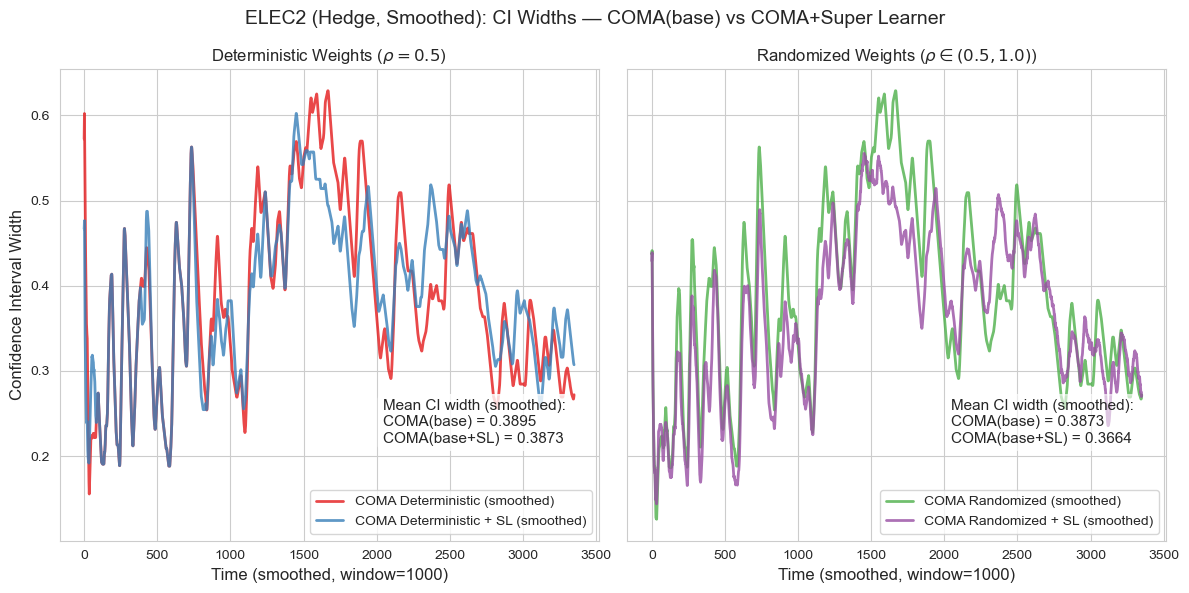

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 4 (already computed): widths ---
coma_width_det     = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

# --- Step 4.1: Smooth with moving average ---
def smooth_series(series, window=500):
    """Apply rolling mean smoothing with specified window size."""
    return np.convolve(series, np.ones(window)/window, mode='valid')

coma_width_det_smooth     = smooth_series(coma_width_det, window=30)
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=30)
coma_width_det_sl_smooth  = smooth_series(coma_width_det_sl, window=30)
coma_width_rand_sl_smooth = smooth_series(coma_width_rand_sl, window=30)

# --- Step 5: Summaries (on smoothed series) ---
print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det_smooth))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand_smooth))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl_smooth))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl_smooth))

# --- Step 6: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det_smooth, label='COMA Deterministic (smoothed)', linewidth=2, alpha=0.8, color=colors[0])
axes[0].plot(coma_width_det_sl_smooth, label='COMA Deterministic + SL (smoothed)', linewidth=2, alpha=0.8, color=colors[1])
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det_smooth)
mean_det_sl = np.nanmean(coma_width_det_sl_smooth)
axes[0].text(0.6, 0.3,
             f"Mean CI width (smoothed):\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand_smooth, label='COMA Randomized (smoothed)', linewidth=2, alpha=0.8, color=colors[2])
axes[1].plot(coma_width_rand_sl_smooth, label='COMA Randomized + SL (smoothed)', linewidth=2, alpha=0.8, color=colors[3])
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time (smoothed, window=1000)", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand_smooth)
mean_rand_sl = np.nanmean(coma_width_rand_sl_smooth)
axes[1].text(0.6, 0.3,
             f"Mean CI width (smoothed):\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("ELEC2 (Hedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()